In [ ]:
import tensorflow as tf, numpy as np, pandas as pd, pickle, glob, os, gc
from keras.models import Model
from keras.layers import LSTM, Conv1D, MaxPooling1D, Dense, Dropout, Concatenate, Input, RepeatVector, TimeDistributed, LayerNormalization, LeakyReLU
from transformers import BertTokenizer, BertForSequenceClassification
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score
from matplotlib import pyplot as plt

# Check if GPU is available
print("GPU Available:", tf.config.list_physical_devices('GPU'))

interval_map = {
        '1m': 1,
        '5m': 2,
        '15m': 3,
        '1h': 4,
        '1d': 5}

GPU Available: []


In [ ]:
def prepare_data(interval_folder, timeframe_name, window_size=60, forecast_horizon=1):
    files = glob.glob(os.path.join(interval_folder, "*.csv"))

    if not files:
      return None

    feature_cols = ['Open', 'High', 'Low', 'Close',
                    'VIX', 'EMA_Dist', '50TD', '200TD',
                    'EMA_Spread', "Rolling_WVAP", "VWAP_Dist", "Hour_Sin",
                    "Hour_Cos", "is_new_york", "is_london", "is_asia",
                    'Volatility', 'RSI', 'ROC', 'BB_Position',
                    "Stoch_K", "Stoch_D"]

    x_train_list, y_trend_train, y_signal_train = [], [], []
    x_test_list, y_trend_test, y_signal_test = [], [], []

    # Initialize scalers
    f_scaler = RobustScaler()
    t_scaler = RobustScaler()
    scalers_fitted = False
    all_feats = []
    target = []
    for f in files:
      temp_df = pd.read_csv(f)
      all_feats.append(temp_df[feature_cols].values.astype('float32'))
      target.append(temp_df[['Close']].values.astype('float32'))

    f_scaler.fit(np.concatenate(all_feats, axis=0))
    t_scaler.fit(np.concatenate(target, axis=0))
    for f in files:
      temp_df = pd.read_csv(f)

      feats = temp_df[feature_cols].values.astype('float32')
      target_price = temp_df[['Close']].values.astype('float32') # regression
      target_signal = temp_df['Signal'].values # classification

      x_scaled = f_scaler.transform(feats)
      y_trend_scaled = t_scaler.transform(target_price)

      x_file, y_t_file, y_s_file = [], [], []
      for i in range(window_size, len(x_scaled) - forecast_horizon):
          x_file.append(x_scaled[i - window_size : i])
          y_t_file.append(y_trend_scaled[i : i + forecast_horizon])
          y_s_file.append(target_signal[i : i + forecast_horizon])

      split = int(len(x_file) * 0.8)
      x_train_list.append(np.array(x_file[:split]))
      y_trend_train.append(np.array(y_t_file[:split]))
      y_signal_train.append(np.array(y_s_file[:split]))

      x_test_list.append(np.array(x_file[split:]))
      y_trend_test.append(np.array(y_t_file[split:]))
      y_signal_test.append(np.array(y_s_file[split:]))

    X_train = np.concatenate(x_train_list)
    Y_trend_train = np.concatenate(y_trend_train)
    Y_signal_train = np.concatenate(y_signal_train)

    X_test = np.concatenate(x_test_list)
    Y_trend_test = np.concatenate(y_trend_test)
    Y_signal_test = np.concatenate(y_signal_test)

    with open(f'scaler_features_{timeframe_name}.pkl', 'wb') as f:
        pickle.dump(f_scaler, f)

    with open(f'scaler_target_{timeframe_name}.pkl', 'wb') as f:
        pickle.dump(t_scaler, f)

    print(f"\n{timeframe_name} Data Prepared:")
    print(f"  X shape: {X_train.shape}")
    print(f"  Y trend shape: {Y_trend_train.shape}")
    print(f"  Y signal shape: {Y_signal_train.shape}")

    return X_train, Y_trend_train, Y_signal_train, X_test, Y_trend_test, Y_signal_test

In [3]:
def build_model(n_timesteps, n_features):
    input_layer = Input(shape=(n_timesteps, n_features), name="input_layer")

    x = Conv1D(filters=16, kernel_size=3, padding ='same')(input_layer)
    x = LeakyReLU(negative_slope=0.05)(x)
    x = MaxPooling1D(pool_size=2)(x)

    x = LSTM(32, return_sequences=False, kernel_regularizer=tf.keras.regularizers.l2(0.005))(x)
    x = LayerNormalization()(x)
    x = Dropout(0.3)(x) # Slightly increased dropout to force generalization

    # External Inputs (Sentiment & Anomaly)
    sentiment_input = Input(shape=(1,), name='sentiment_input')
    anomaly_input = Input(shape=(1,), name='anomaly_input')

    # Merge Time-Series with External Factors
    merged = Concatenate()([x, sentiment_input, anomaly_input])

    # Dense Network
    merged = Dense(32)(merged)
    merged = LeakyReLU(negative_slope=0.05)(merged)
    merged = Dropout(0.1)(merged)

    # Output Layer
    signal_output = Dense(3, activation='softmax', name='signal_output')(merged)

    model = Model(inputs=[input_layer, sentiment_input, anomaly_input],
                  outputs=signal_output)

    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)

    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy']
                  )

    return model

In [4]:
def prepare_inputs(x_data, sentiment_data, anomaly_data):
    return [x_data, sentiment_data.reshape(-1, 1), anomaly_data.reshape(-1, 1)]

In [5]:
def build_autoencoder(n_timesteps, n_features):
    # Input: (60, 11)
    input_layer = Input(shape=(n_timesteps, n_features))

    # --- ENCODER ---
    # We compress the 60 steps of data into a single vector
    encoder = LSTM(64, return_sequences=True)(input_layer)
    encoder = LSTM(32, return_sequences=False)(encoder) # The "Bottleneck"

    # --- DECODER ---
    # We take that 32-unit vector and try to expand it back to (60, 11)
    decoder = RepeatVector(n_timesteps)(encoder)
    decoder = LSTM(32, return_sequences=True)(decoder)
    decoder = LSTM(64, return_sequences=True)(decoder)

    # The output must match the exact shape of the input
    output_layer = TimeDistributed(Dense(n_features))(decoder)

    model = Model(inputs=input_layer, outputs=output_layer)
    model.compile(optimizer='adam', loss='mae')
    return model

def prepare_anomaly_data(df, window_size=30):
    feat_cols = ['Open', 'High', 'Low', 'Close', 'VIX', 'RSI', 'EMA_Dist', 'Volatility']
    data = df[feat_cols].values
    df = df.replace([np.inf, -np.inf], np.nan).dropna()
    if df.isnull().values.any():
        print("Warning: NaNs still present in the data!")
    sequences = []
    for i in range(len(data) - window_size):
        sequences.append(data[i: i + window_size])

    return np.array(sequences)

def black_swan(model, current_window, threshold=0.15):
    prediction = model.predict(current_window, verbose=0)

    loss = np.mean(np.abs(current_window-prediction))
    is_anomaly = loss > threshold

    return is_anomaly, loss

In [ ]:
class SentimentAnalyser:
    def __init__(self, prob_buy, prob_sell, max_weight):
        print("Loading finbert")

        self.tokenizer = BertTokenizer.from_pretrained('ProsusAI/finbert')
        self.model = BertForSequenceClassification.from_pretrained('ProsusAI/finbert', from_pt=True)
        self.prob_buy = prob_buy
        self.prob_sell = prob_sell
        self.max_weight = 0.20

    def get_sentiment_score(self, headlines):
        if not headlines:
            return 0.0

        tokenised_input = self.tokenizer(headlines, padding=True, truncation=True, return_tensors='tf')

        output = self.model(tokenised_input)
        probs = tf.nn.softmax(output.logits, axis=-1)

        pos_score = probs[0][0].numpy()
        neg_score = probs[0][1].numpy()

        final_score = pos_score - neg_score

        return final_score

    def apply_sentiment_scaling(self, prob_buy, prob_sell, sentiment_score):

      # Start with default 1.0 multipliers (No change)
      buy_multiplier = 1.0
      sell_multiplier = 1.0

      if sentiment_score > 0:
          # Bullish News: Boost Buy, Penalize Sell
          buy_multiplier = 1.0 + (sentiment_score * self.max_weight)
          sell_multiplier = 1.0 - (sentiment_score * self.max_weight)

      elif sentiment_score < 0:
          # Bearish News: Boost Sell, Penalize Buy
          # We use abs() to convert the negative score into a positive multiplier addition
          sell_multiplier = 1.0 + (abs(sentiment_score) * self.max_weight)
          buy_multiplier = 1.0 - (abs(sentiment_score) * self.max_weight)

      # Apply the multipliers
      adjusted_buy = self.prob_buy * buy_multiplier
      adjusted_sell = self.prob_sell * sell_multiplier

      # Safety Cap: Ensure probabilities mathematically cannot exceed 0.99
      adjusted_buy = min(0.99, adjusted_buy)
      adjusted_sell = min(0.99, adjusted_sell)

      return adjusted_buy, adjusted_sell

In [7]:
def train():
  base_path = '/content/sample_data/data'
  timeframes = ['1m', '5m', '15m', '1h', '1d']

  for timeframe in timeframes:
      print(f"\n--- Processing Timeframe: {timeframe} ---")
      folder_path = os.path.join(base_path, timeframe)

      data = prepare_data(folder_path, timeframe, forecast_horizon=1)
      if data is None: continue
      x_train, y_train_trend, y_train_signal, x_test, y_test_trend, y_test_signal = data

      print(f"Training Autoencoder for {timeframe}...")
      ae = build_autoencoder(x_train.shape[1], x_train.shape[2])
      ae.fit(x_train,
          x_train,
          epochs=20,
          batch_size=128,
          validation_split=0.1,
          shuffle=False,
          verbose=0)
      ae.save(f'autoencoder_{timeframe}.h5')

      train_recon = ae.predict(x_train)
      train_anom = np.mean(np.abs(x_train - train_recon), axis=(1, 2)).reshape(-1, 1)

      test_recon = ae.predict(x_test)
      test_anom = np.mean(np.abs(x_test - test_recon), axis=(1, 2)).reshape(-1, 1)

      anom_scaler = MinMaxScaler()
      train_anom_scaled = anom_scaler.fit_transform(train_anom)
      test_anom_scaled = anom_scaler.transform(test_anom)

      with open(f'scaler_anom_{timeframe}.pkl', 'wb') as f:
          pickle.dump(anom_scaler, f)

      train_sent = np.zeros((len(x_train), 1))
      test_sent = np.zeros((len(x_test), 1))

      # 2. Flatten your signal array to ensure it is 1D
      y_sig_flat = y_train_signal.flatten()

      class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_sig_flat),
        y=y_sig_flat
      )

      # 3. Create the dictionary from the sklearn output
      class_weights_dict = dict(enumerate(class_weights))
      print(f"Sell: {class_weights_dict.get(0, 1.0):.2f}")
      print(f"Hold: {class_weights_dict.get(1, 1.0):.2f}")
      print(f"Buy:  {class_weights_dict.get(2, 1.0):.2f}\n")

      # 3. Map the weights to every single sample for the Classification Head
      signal_sample_weights = np.array([class_weights_dict.get(int(y), 1.0) for y in y_sig_flat])

      print(f"Training Predictor for {timeframe} timeframe...")

      predictor = build_model(x_train.shape[1], x_train.shape[2])
      predictor.fit(
          x=[x_train, train_sent, train_anom_scaled],
          y=y_sig_flat,
          sample_weight=signal_sample_weights,
          validation_split=0.1,
          epochs=30,
          batch_size=64,
          callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
          shuffle=True
      )
      predictor.save(f'predictor_{timeframe}.h5')

      del x_train, y_train_trend, y_train_signal, x_test, y_test_trend, y_test_signal, predictor
      gc.collect()
      tf.keras.backend.clear_session()

      print(f"saved predictor_{timeframe}.h5, autoencoder_{timeframe}.h5")
      print(f"saved scaler_features_{timeframe}.pkl, scaler_target_{timeframe}.pkl, scaler_anom_{timeframe}.pkl")

In [8]:
def check():
  import pickle

  # Load the target_scaler for the '5m' timeframe, as this was the last one processed
  with open('scaler_target_1h.pkl', 'rb') as f:
      loaded_target_scaler = pickle.load(f)

  print("Properties of the loaded target_scaler (RobustScaler):")
  print(f"Center (median): {loaded_target_scaler.center_}")
  print(f"Scale (interquartile range): {loaded_target_scaler.scale_}")

In [17]:
def find_optimal_thresholds(probabilities, y_true):
    print("Starting PRO-TRADER Threshold Optimization...")
    thresholds = np.arange(0.00, 0.60, 0.02)

    best_trade_score = 0
    best_buy_thresh = 0.33
    best_sell_thresh = 0.33

    # Pre-calculate the AI's #1 choices to speed up the loop
    max_classes = np.argmax(probabilities, axis=1)
    max_probs = np.max(probabilities, axis=1)

    for buy_t in thresholds:
        for sell_t in thresholds:
            simulated_predictions = []
            for i in range(len(probabilities)):
                # Must be the #1 choice AND pass the strict threshold
                if max_classes[i] == 2 and max_probs[i] >= buy_t:
                    simulated_predictions.append(2)
                elif max_classes[i] == 0 and max_probs[i] >= sell_t:
                    simulated_predictions.append(0)
                else:
                    simulated_predictions.append(1)

            scores = f1_score(y_true, simulated_predictions, average=None, labels=[0, 1, 2])
            trade_f1 = (scores[0] + scores[2]) / 2.0

            if trade_f1 > best_trade_score:
                best_trade_score = trade_f1
                best_buy_thresh = buy_t + 0.01
                best_sell_thresh = sell_t + 0.01

    print("-" * 30)
    print(f"OPTIMIZATION COMPLETE!")
    print(f"Maximized Trade F1-Score: {best_trade_score:.4f}")
    print(f"Optimal BUY Threshold:  {best_buy_thresh:.2f}")
    print(f"Optimal SELL Threshold: {best_sell_thresh:.2f}")
    print("-" * 30)

    return best_buy_thresh, best_sell_thresh


def apply_signal_gap(predictions, min_gap=5):
    filtered = predictions.copy()
    last_signal_idx = -min_gap
    for i in range(len(filtered)):
        if filtered[i] != 1:  # Buy or Sell
            if i - last_signal_idx < min_gap:
                filtered[i] = 1  # suppress to Hold
            else:
                last_signal_idx = i
    return filtered

In [27]:
def predict_and_visualise(timeframe):
    # 1. Load Model & Scalers
    custom_objects = {'mse': tf.keras.losses.MeanAbsoluteError, 'mae': tf.keras.losses.MeanAbsoluteError}
    model = tf.keras.models.load_model(f'predictor_{timeframe}.h5', custom_objects=custom_objects)
    ae_model = tf.keras.models.load_model(f'autoencoder_{timeframe}.h5', custom_objects=custom_objects)

    with open(f'scaler_target_{timeframe}.pkl', 'rb') as f:
        target_scaler = pickle.load(f)
    with open(f'scaler_anom_{timeframe}.pkl', 'rb') as f:
        anom_scaler = pickle.load(f)

    # --- FIX 1: UNPACK TEST DATA CORRECTLY ---
    _, _, _, X_te, Y_te_trend, Y_te_signal = prepare_data('/content/sample_data/data/1h', timeframe)

    # 2. Get Anomaly Scores
    test_ae_preds = ae_model.predict(X_te, verbose=0)
    test_anomaly_raw = np.mean(np.abs(X_te - test_ae_preds), axis=(1, 2)).reshape(-1, 1)
    test_anomaly = anom_scaler.transform(test_anomaly_raw)
    test_sentiment = np.zeros((len(test_anomaly), 1))

    # 3. Predict Returns
    signal_output = model.predict([X_te, test_sentiment, test_anomaly])

    # --- FIX 2: RECONSTRUCT PRICE FROM LOG RETURNS ---
    # Unscale the returns
    actual_returns = target_scaler.inverse_transform(Y_te_trend.reshape(-1, 1))

    # Create a Price Path starting at 100
    end_display = 2000
    # Price = Start * exp(cumulative_sum_of_returns)
    y_true_price = 100 * np.exp(np.cumsum(actual_returns[:end_display]))

    actual_classes_full = Y_te_signal.flatten()

    probabilities = signal_output
    raw_predictions = np.argmax(probabilities, axis=1)

    # 1. Find the optimal thresholds
    best_buy, best_sell = find_optimal_thresholds(probabilities, actual_classes_full)

    # 2. GENERATE PRODUCTION PREDICTIONS USING THE THRESHOLDS
    max_classes = np.argmax(probabilities, axis=1)
    max_probs = np.max(probabilities, axis=1)

    production_predictions = []
    for i in range(len(probabilities)):
        if max_classes[i] == 2 and max_probs[i] >= 0.45:
            production_predictions.append(2) # Buy
        elif max_classes[i] == 0 and max_probs[i] >= 0.45:
            production_predictions.append(0) # Sell
        else:
            production_predictions.append(1) # Hold

    production_predictions = np.array(production_predictions)

    # 3. Visualization
    plt.figure(figsize=(16, 8))
    plt.plot(y_true_price, label='Actual Price (Normalized)', color='#2c3e50', linewidth=2)

    colors = ['#c0392b', '#bdc3c7', '#27ae60']
    labels = ['Sell', 'Hold', 'Buy']

    current_position = 1

    for i in range(end_display):
        sig = production_predictions[i]

        if sig != 1 and sig != current_position:
            plt.scatter(i, y_true_price[i], color=colors[sig], s=100, edgecolors='black', zorder=5)
            current_position = sig

        elif sig == 1:
            current_position = 1

    plt.title(f"Hybrid Strategy: {timeframe} Momentum Forecast (Base 100)")
    plt.legend()
    plt.show()

    from sklearn.metrics import classification_report

    print("\n--- PURE AI PREDICTIONS (No Thresholds) ---")
    print(classification_report(actual_classes_full, raw_predictions, target_names=labels))

    print(f"\n--- PRODUCTION PERFORMANCE (Optimized Thresholds: Buy={best_buy:.2f}, Sell={best_sell:.2f}) ---")
    print(classification_report(actual_classes_full, production_predictions, target_names=labels))




In [12]:
train()


--- Processing Timeframe: 1m ---

1m Data Prepared:
  X shape: (32329, 60, 22)
  Y trend shape: (32329, 1, 1)
  Y signal shape: (32329, 1)
Training Autoencoder for 1m...


1011/1011 ━━━━━━━━━━━━━━━━━━━━ 22s 21ms/step
253/253 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step
Sell: 1.15
Hold: 0.77
Buy:  1.20

Training Predictor for 1m timeframe...
Epoch 1/30
455/455 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.4360 - loss: 1.2101 - val_accuracy: 0.4516 - val_loss: 1.1560
Epoch 2/30
455/455 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.5230 - loss: 1.0360 - val_accuracy: 0.4457 - val_loss: 1.1228
Epoch 3/30
455/455 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.5417 - loss: 0.9914 - val_accuracy: 0.4244 - val_loss: 1.1147
Epoch 4/30
455/455 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5598 - loss: 0.9650 - val_accuracy: 0.4491 - val_loss: 1.1030
Epoch 5/30
455/455 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.5729 - loss: 0.9469 - val_accuracy: 0.4234 - val_loss: 1.1045
Epoch 6/30
455/455 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5868 - loss: 0.9220 - val_accuracy: 0.4330 - val_loss: 1.0931
Epoch 7/30
455/455 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0

saved predictor_1m.h5, autoencoder_1m.h5
saved scaler_features_1m.pkl, scaler_target_1m.pkl, scaler_anom_1m.pkl

--- Processing Timeframe: 5m ---

5m Data Prepared:
  X shape: (65931, 60, 22)
  Y trend shape: (65931, 1, 1)
  Y signal shape: (65931, 1)
Training Autoencoder for 5m...


2061/2061 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step
516/516 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step
Sell: 1.27
Hold: 0.70
Buy:  1.28

Training Predictor for 5m timeframe...
Epoch 1/30
928/928 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.4095 - loss: 1.2284 - val_accuracy: 0.4469 - val_loss: 1.0900
Epoch 2/30
928/928 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.4976 - loss: 1.0450 - val_accuracy: 0.4368 - val_loss: 1.0532
Epoch 3/30
928/928 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.5270 - loss: 1.0023 - val_accuracy: 0.4668 - val_loss: 1.0361
Epoch 4/30
928/928 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.5471 - loss: 0.9738 - val_accuracy: 0.5036 - val_loss: 1.0261
Epoch 5/30
928/928 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.5554 - loss: 0.9652 - val_accuracy: 0.5130 - val_loss: 1.0354
Epoch 6/30
928/928 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.5620 - loss: 0.9489 - val_accuracy: 0.5288 - val_loss: 1.0305
Epoch 7/30
928/928 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - acc

saved predictor_5m.h5, autoencoder_5m.h5
saved scaler_features_5m.pkl, scaler_target_5m.pkl, scaler_anom_5m.pkl

--- Processing Timeframe: 15m ---

15m Data Prepared:
  X shape: (21783, 60, 22)
  Y trend shape: (21783, 1, 1)
  Y signal shape: (21783, 1)
Training Autoencoder for 15m...


...

saved predictor_15m.h5, autoencoder_15m.h5
saved scaler_features_15m.pkl, scaler_target_15m.pkl, scaler_anom_15m.pkl

--- Processing Timeframe: 1h ---

1h Data Prepared:
  X shape: (69148, 60, 22)
  Y trend shape: (69148, 1, 1)
  Y signal shape: (69148, 1)
Training Autoencoder for 1h...


2161/2161 ━━━━━━━━━━━━━━━━━━━━ 44s 20ms/step
541/541 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step
Sell: 1.39
Hold: 0.63
Buy:  1.42

Training Predictor for 1h timeframe...
Epoch 1/30
973/973 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.4032 - loss: 1.2296 - val_accuracy: 0.4038 - val_loss: 1.1311
Epoch 2/30
973/973 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.4823 - loss: 1.0701 - val_accuracy: 0.4551 - val_loss: 1.1035
Epoch 3/30
973/973 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.5015 - loss: 1.0334 - val_accuracy: 0.3938 - val_loss: 1.0905
Epoch 4/30
973/973 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.5028 - loss: 1.0196 - val_accuracy: 0.4537 - val_loss: 1.0779
Epoch 5/30
973/973 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.5090 - loss: 1.0121 - val_accuracy: 0.4706 - val_loss: 1.0645
Epoch 6/30
973/973 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.5166 - loss: 0.9917 - val_accuracy: 0.4723 - val_loss: 1.0828
Epoch 7/30
973/973 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - acc

saved predictor_1h.h5, autoencoder_1h.h5
saved scaler_features_1h.pkl, scaler_target_1h.pkl, scaler_anom_1h.pkl

--- Processing Timeframe: 1d ---

1d Data Prepared:
  X shape: (24315, 60, 22)
  Y trend shape: (24315, 1, 1)
  Y signal shape: (24315, 1)
Training Autoencoder for 1d...


760/760 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step
Sell: 1.72
Hold: 0.56
Buy:  1.60

Training Predictor for 1d timeframe...
Epoch 1/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.3925 - loss: 1.2784 - val_accuracy: 0.4058 - val_loss: 1.0131
Epoch 2/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.4801 - loss: 1.1187 - val_accuracy: 0.4058 - val_loss: 1.0210
Epoch 3/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5054 - loss: 1.0439 - val_accuracy: 0.3779 - val_loss: 1.1002
Epoch 4/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.5302 - loss: 0.9870 - val_accuracy: 0.4864 - val_loss: 1.0909
Epoch 5/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5558 - loss: 0.9454 - val_accuracy: 0.4564 - val_loss: 1.2739
Epoch 6/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.5703 - loss: 0.9086 - val_accuracy: 0.4178 - val_loss: 1.0617


saved predictor_1d.h5, autoencoder_1d.h5
saved scaler_features_1d.pkl, scaler_target_1d.pkl, scaler_anom_1d.pkl


In [13]:
check()

Properties of the loaded target_scaler (RobustScaler):
Center (median): [0.]
Scale (interquartile range): [0.00107932]



5m Data Prepared:
  X shape: (69148, 60, 22)
  Y trend shape: (69148, 1, 1)
  Y signal shape: (69148, 1)
541/541 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Starting PRO-TRADER Threshold Optimization...
------------------------------
OPTIMIZATION COMPLETE!
Maximized Trade F1-Score: 0.3051
Optimal BUY Threshold:  0.01
Optimal SELL Threshold: 0.35
------------------------------


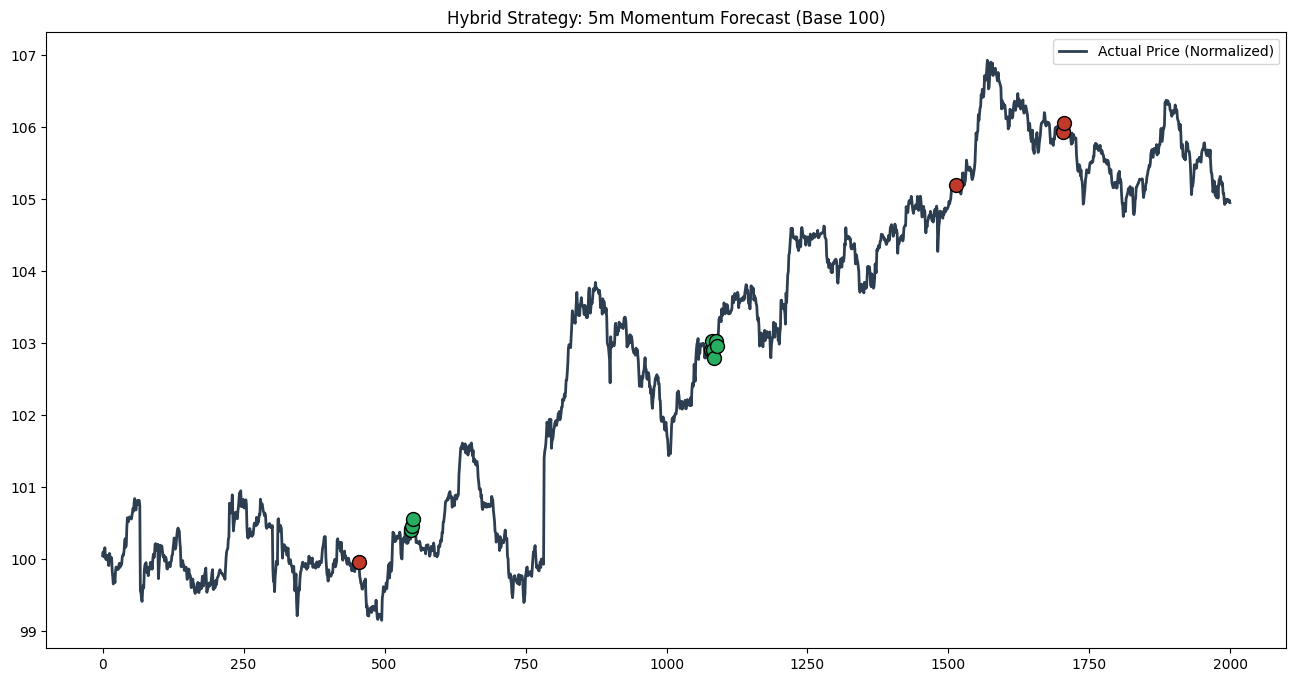


--- PURE AI PREDICTIONS (No Thresholds) ---
              precision    recall  f1-score   support

        Sell       0.28      0.35      0.31      3612
        Hold       0.61      0.52      0.56      9182
         Buy       0.28      0.31      0.30      4498

    accuracy                           0.43     17292
   macro avg       0.39      0.39      0.39     17292
weighted avg       0.46      0.43      0.44     17292


--- PRODUCTION PERFORMANCE (Optimized Thresholds: Buy=0.01, Sell=0.35) ---
              precision    recall  f1-score   support

        Sell       0.33      0.08      0.12      3612
        Hold       0.54      0.91      0.68      9182
         Buy       0.28      0.06      0.10      4498

    accuracy                           0.51     17292
   macro avg       0.38      0.35      0.30     17292
weighted avg       0.43      0.51      0.41     17292



In [28]:
predict_and_visualise('5m')